In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/dataset"))

['test', 'Meta', 'Train.csv', 'Test', 'Test.csv', 'train', 'Meta.csv', 'meta', 'Train']


In [ ]:
import os

print("Train Exists:",
      os.path.exists("/content/dataset/Train"))

print("Test Exists:",
      os.path.exists("/content/dataset/Test"))



Train Exists: True
Test Exists: True


In [ ]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd
import random
import os
from PIL import Image
import numpy as np




In [ ]:

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

Using Device: cuda


In [ ]:

# TRAFFIC SIGN CLASSIFICATION USING CNN
# Dataset: GTSRB
# Compare:
# CNN + Adam
# CNN + SGD



# Reproducibility
torch.manual_seed(42)
random.seed(42)


# Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 10
num_classes = 43


# Dataset Paths
train_path = "/content/dataset/Train"
test_path  = "/content/dataset/Test"


# Transform + Preprocessing
transform = transforms.Compose([

    # Resize Images
    transforms.Resize((32, 32)),

    # Data Augmentation
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),

    # Convert to Tensor
    transforms.ToTensor(),

    # Normalize
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])


In [ ]:

# Full Training Dataset
full_dataset = torchvision.datasets.ImageFolder(
    root=train_path,
    transform=transform
)


# Train / Validation Split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)


# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


# Classes
classes = full_dataset.classes

print("Number of Classes:", len(classes))

Number of Classes: 43


In [ ]:

# CNN MODEL

class TrafficSignCNN(nn.Module):

    def __init__(self, num_classes=43):

        super().__init__()

        self.features = nn.Sequential(

            # First Conv Block
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),


            # Second Conv Block
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),


            # Third Conv Block
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 256),

            nn.ReLU(),

            # Dropout
            nn.Dropout(0.5),

            # Output Layer
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


In [ ]:

# TRAIN + VALIDATION FUNCTION
def train_and_evaluate(model, optimizer, model_name):

    criterion = nn.CrossEntropyLoss()

    train_acc_list = []
    val_acc_list = []

    train_loss_list = []
    val_loss_list = []

    print(f"\n===== Training {model_name} =====")


    # Training Loop
    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for imgs, labels in train_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

        train_accuracy = 100 * correct / total
        train_loss = running_loss / len(train_loader)

        train_acc_list.append(train_accuracy)
        train_loss_list.append(train_loss)


        # Validation
        model.eval()

        correct = 0
        total = 0
        running_loss = 0

        with torch.no_grad():

            for imgs, labels in val_loader:

                imgs = imgs.to(device)
                labels = labels.to(device)

                outputs = model(imgs)

                loss = criterion(outputs, labels)

                running_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)

                correct += (preds == labels).sum().item()

                total += labels.size(0)

        val_accuracy = 100 * correct / total
        val_loss = running_loss / len(val_loader)

        val_acc_list.append(val_accuracy)
        val_loss_list.append(val_loss)

        print(
            f"{model_name} Epoch {epoch+1} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    return (
        val_accuracy,
        val_loss,
        train_acc_list,
        val_acc_list,
        train_loss_list,
        val_loss_list
    )

In [ ]:

# EXPERIMENT 1 : ADAM
model_adam = TrafficSignCNN(num_classes).to(device)

optimizer_adam = torch.optim.Adam(
    model_adam.parameters(),
    lr=learning_rate
)

(
    adam_acc,
    adam_loss,
    adam_train_acc,
    adam_val_acc,
    adam_train_loss,
    adam_val_loss
) = train_and_evaluate(
    model_adam,
    optimizer_adam,
    "CNN + Adam"
)


# EXPERIMENT 2 : SGD
model_sgd = TrafficSignCNN(num_classes).to(device)

optimizer_sgd = torch.optim.SGD(
    model_sgd.parameters(),
    lr=learning_rate
)

(
    sgd_acc,
    sgd_loss,
    sgd_train_acc,
    sgd_val_acc,
    sgd_train_loss,
    sgd_val_loss
) = train_and_evaluate(
    model_sgd,
    optimizer_sgd,
    "CNN + SGD"
)



# RESULTS COMPARISON TABLE
results = pd.DataFrame({

    "Model": [
        "CNN + Adam",
        "CNN + SGD"
    ],

    "Accuracy": [
        adam_acc,
        sgd_acc
    ],

    "Loss": [
        adam_loss,
        sgd_loss
    ]
})

print("\n===== FINAL RESULTS =====")
print(results)



===== Training CNN + Adam =====
CNN + Adam Epoch 1 | Train Acc: 46.49% | Val Acc: 78.27%
CNN + Adam Epoch 2 | Train Acc: 77.54% | Val Acc: 89.39%
CNN + Adam Epoch 3 | Train Acc: 86.17% | Val Acc: 94.63%
CNN + Adam Epoch 4 | Train Acc: 89.32% | Val Acc: 94.89%
CNN + Adam Epoch 5 | Train Acc: 91.28% | Val Acc: 96.98%
CNN + Adam Epoch 6 | Train Acc: 92.50% | Val Acc: 95.50%
CNN + Adam Epoch 7 | Train Acc: 93.74% | Val Acc: 97.50%
CNN + Adam Epoch 8 | Train Acc: 94.52% | Val Acc: 97.60%
CNN + Adam Epoch 9 | Train Acc: 94.69% | Val Acc: 97.92%
CNN + Adam Epoch 10 | Train Acc: 94.99% | Val Acc: 98.10%

===== Training CNN + SGD =====
CNN + SGD Epoch 1 | Train Acc: 9.72% | Val Acc: 20.06%
CNN + SGD Epoch 2 | Train Acc: 17.70% | Val Acc: 27.39%
CNN + SGD Epoch 3 | Train Acc: 23.96% | Val Acc: 32.19%
CNN + SGD Epoch 4 | Train Acc: 29.56% | Val Acc: 37.53%
CNN + SGD Epoch 5 | Train Acc: 34.10% | Val Acc: 42.59%
CNN + SGD Epoch 6 | Train Acc: 37.69% | Val Acc: 45.82%
CNN + SGD Epoch 7 | Train Acc

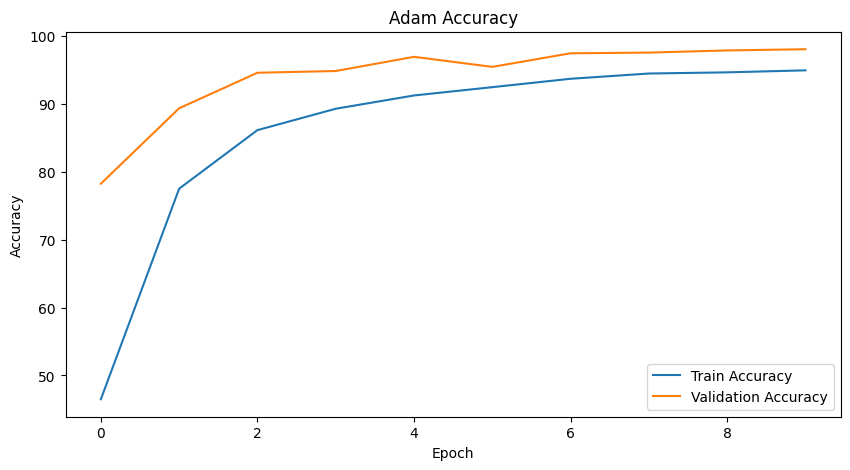

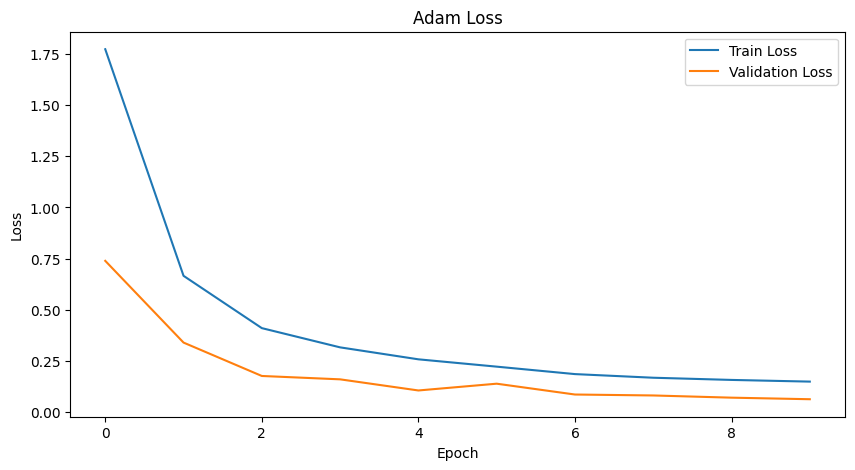

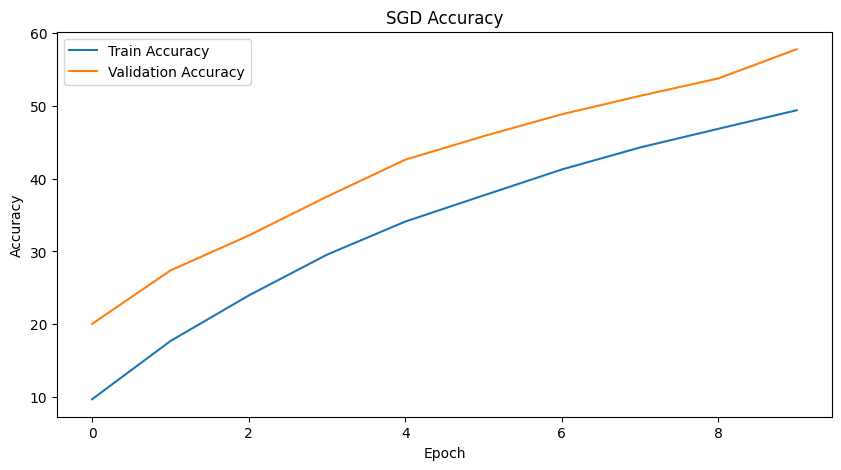

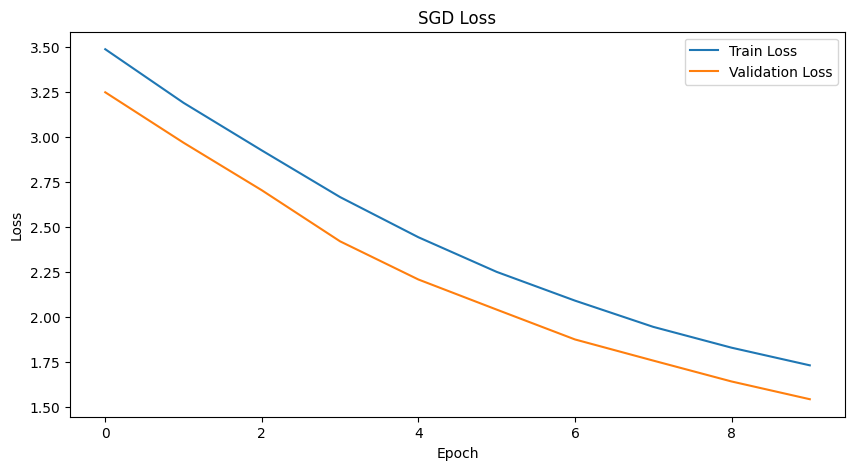

In [ ]:

# VISUALIZATION


# Adam Accuracy Curve
plt.figure(figsize=(10,5))

plt.plot(adam_train_acc)
plt.plot(adam_val_acc)

plt.title("Adam Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train Accuracy",
    "Validation Accuracy"
])

plt.show()


# Adam Loss Curve
plt.figure(figsize=(10,5))

plt.plot(adam_train_loss)
plt.plot(adam_val_loss)

plt.title("Adam Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train Loss",
    "Validation Loss"
])

plt.show()


# SGD Accuracy Curve
plt.figure(figsize=(10,5))

plt.plot(sgd_train_acc)
plt.plot(sgd_val_acc)

plt.title("SGD Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train Accuracy",
    "Validation Accuracy"
])

plt.show()


# SGD Loss Curve
plt.figure(figsize=(10,5))

plt.plot(sgd_train_loss)
plt.plot(sgd_val_loss)

plt.title("SGD Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train Loss",
    "Validation Loss"
])

plt.show()

In [ ]:

# TEST ON NEW IMAGE


# Example image from Test folder
image_name = os.listdir(test_path)[0]

image_path = os.path.join(test_path, image_name)

print("\nTesting Image:", image_name)

# Read Image
image = Image.open(image_path).convert("RGB")

# Apply Transform
input_image = transform(image)

# Add Batch Dimension
input_image = input_image.unsqueeze(0).to(device)

# Prediction
model_adam.eval()

with torch.no_grad():

    prediction = model_adam(input_image)

    predicted_class = torch.argmax(prediction, dim=1).item()

    confidence = torch.softmax(prediction, dim=1).max().item()

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)


Testing Image: 04616.png
Predicted Class: 32
Confidence: 0.9991784691810608
